In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn import metrics
import scipy.special as sp
plt.style.use('seaborn-v0_8-bright')
plt.rcParams["font.family"] = "monospace"
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True

import import_helper
import_helper.add_functions()
import neuruloid_segmentation.process_intensities as process
import neuruloid_segmentation.fitting_intensities as fit
import neuruloid_segmentation.utils as u

### Fitting TBXT data with simple exponential model

For a simple diffusion-degradation model with radial symmetry, we fit the equation
<!-- \begin{align}
c_s(r) = \frac{1}{1+e^{-2L/\lambda}} (e^{-x/\lambda} + e^{-2L/\lambda}e^{x/\lambda})
\end{align} -->

\begin{align}
    c_s(r) = \frac{I_0(\gamma r)}{I_0(\gamma)}
\end{align}

where we fix the radius of circular domain to be $R=1$, so $0\leq r \leq 1$. We obtain the decay length scale $\gamma$, where $\gamma=\sqrt{k/D}$, then simulate in 2D (show no steady state if there is constant increased sensitivity to activator at the neuruloid edge??), where $\gamma \propto L$, where $L$ is the micropattern radius.

In [2]:
# obtain TBXT data
TBXT_intensity_data_folder = "../intensity_data"
ctrl_circle_data = "single_z_slices_24hr/circle_ctrl"
data_folder_path = os.path.join(TBXT_intensity_data_folder, ctrl_circle_data)

data_names_sizes = {"ctrl_250":250, "ctrl_350":350, 
                    "ctrl_400":400, "ctrl_500":500}
data_color = {"ctrl_250":"red", "ctrl_350":"blue", 
              "ctrl_400":"green", "ctrl_500":"purple"}

In [3]:
# function to fit
def c_s(x, lam):
    return (np.exp(-x/lam) + np.exp(-2/lam) * np.exp(x/lam)) / (1 + np.exp(-2/lam))

def bessel_function_solution(r, gamma):
    return sp.iv(0, r * gamma) / sp.iv(0, gamma)

In [4]:
def fitting(xdata, ydata):
    initial_guess = [5]
    popt, pcov = curve_fit(bessel_function_solution, xdata, ydata, p0=initial_guess)
    fitted_gamma = popt[0]
    gamma_err = np.sqrt(np.diag(pcov))[0]
    return fitted_gamma, gamma_err

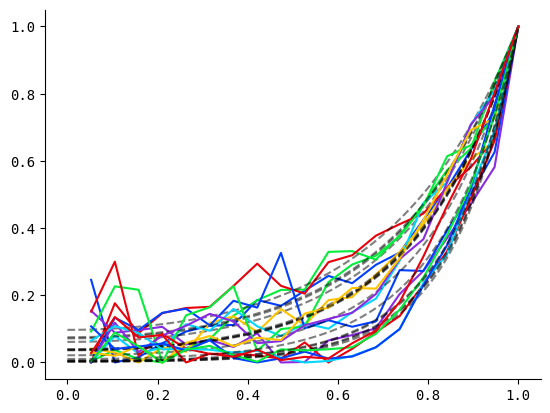

In [5]:
# make a dictionary of all the lambda values for different radii
fitted_gamma_array = []
radius_sizes_array = []

for data_name in list(data_names_sizes.keys()):

    sample_names = os.listdir((os.path.join(data_folder_path, data_name)))

    for i in range(len(sample_names)):

        # get df of the sample
        df = pd.read_csv(os.path.join(f"{data_folder_path}/{data_name}", sample_names[i]))
        discrete_dict = np.linspace(0, np.max(df["distance"].to_numpy()), 20)
        normalise_max_df = process.process_raw_to_norm_dataframe(df,
                                                                 discrete_dict,
                                                                 channels=[3],
                                                                 subtract_bg=[True])
        
        tbxt_dist = discrete_dict / np.max(discrete_dict)
        tbxt_intensity = normalise_max_df["channel_3"].to_numpy()
        tbxt_intensity = tbxt_intensity[::-1]

        fitted_gamma, _ = fitting(tbxt_dist[1:], tbxt_intensity)

        plt.plot(tbxt_dist[1:], tbxt_intensity, label=sample_names[i])
        x = np.linspace(0, 1, 100)
        plt.plot(x, bessel_function_solution(x, fitted_gamma), linestyle='--', color='black', alpha=0.5)

        fitted_gamma_array.append(fitted_gamma)
        radius_sizes_array.append(data_names_sizes[data_name] / 2)
 

In [6]:
print(np.array(fitted_gamma_array))

[4.42200765 4.24141398 3.89205446 7.25325891 4.96444528 4.90911563
 5.59893333 4.19059765 7.72529381 5.01550195 4.98440932 7.94826792
 7.63809256 7.16330112 6.4051104 ]


In [7]:
radius = np.array(radius_sizes_array)
gamma = np.array(fitted_gamma_array)
slope, r_squared = u.fit_proportional_line_and_evaluate(radius, gamma)
print(slope)

0.030023736695687434


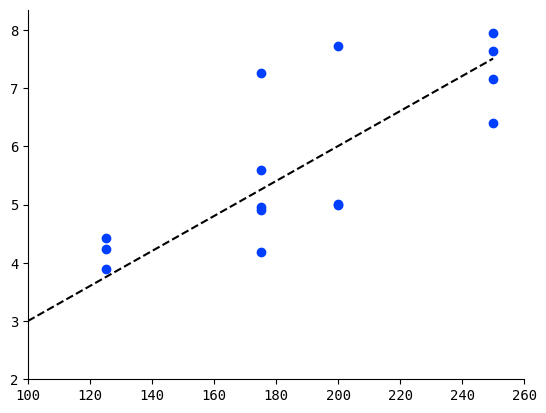

In [8]:
# plot linear line
fig, ax = plt.subplots()
ax.scatter(radius, gamma)
x = np.linspace(0, 250, 10)
y = slope * x 
ax.plot(x, y, color="black", linestyle="--")
ax.set_xlim(100, 260)
ax.set_ylim(2,)
fig.savefig("sdd_fitting.png", transparent=True)

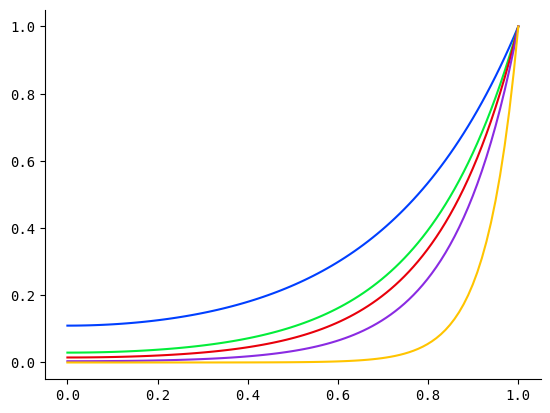

In [9]:
# plot the gradient
diameter_values = np.array([250, 350, 400, 500, 1000])
radius_values = diameter_values / 2
gamma_values = 0.03 * radius_values
r = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i in range(len(gamma_values)):
    steady_state_profile = bessel_function_solution(r, gamma_values[i])
    ax.plot(r, steady_state_profile)

fig.savefig("sdd_gradient.png", transparent=True)